In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [2]:
input_dir = "convergence_results_final"
mcmc_main_swd = np.load(os.path.join(input_dir, "rel_swd_obs.npy"))
mcmc_med_swd = np.load(os.path.join(input_dir, "rel_swd_med.npy"))
mcmc_98_swd = np.load(os.path.join(input_dir, "rel_swd_98.npy"))

mcmc_main_avg = np.mean(mcmc_main_swd, axis=0)
mcmc_med_avg = np.mean(mcmc_med_swd, axis=0)
mcmc_98_avg = np.mean(mcmc_98_swd, axis=0)
mcmc_main_std = np.std(mcmc_main_swd, axis=0)
mcmc_med_std = np.std(mcmc_med_swd, axis=0)
mcmc_98_std = np.std(mcmc_98_swd, axis=0)

In [3]:
mala_swd = np.load("convergence_results_mala/rel_swd.npy")
mala_swd

array([0.55963002, 0.55772481, 0.55771386, 0.55449874, 0.55052813,
       0.5436392 , 0.53479717, 0.5243687 , 0.5054698 , 0.47902945,
       0.44779653, 0.41442952, 0.37483863, 0.33643719, 0.31941102,
       0.28086863, 0.27240013, 0.25532573, 0.23448482])

In [14]:
mcmc_main_avg

array([0.50589263, 0.46891286, 0.43739307, 0.41086209, 0.38379817,
       0.35424315, 0.3109758 , 0.26596499, 0.21043052, 0.16472626,
       0.11872309, 0.08625766, 0.06464867, 0.04680183, 0.04214328,
       0.0352865 , 0.03062133, 0.0275625 ])

In [5]:
si_input = "convergence_results"
ntrials = 10
nsamps = 23
si_swd = np.empty((ntrials, nsamps, 3))
for i in range(ntrials):
    si_samps = np.load(os.path.join(si_input, f"run_{i:02d}", "rel_swd_array.npy"))
    si_swd[i] = si_samps

si_main = si_swd[:, :, 0]
si_med = si_swd[:, :, 1]
si_98 = si_swd[:, :, 2]
si_main_avg = np.mean(si_main, axis=0)
si_med_avg = np.mean(si_med, axis=0)
si_98_avg = np.mean(si_98, axis=0)
si_main_std = np.std(si_main, axis=0)
si_med_std = np.std(si_med, axis=0)
si_98_std = np.std(si_98, axis=0)

In [6]:
si_main_std

array([0.0650462 , 0.06412232, 0.03073051, 0.05805303, 0.05761845,
       0.0339617 , 0.01397947, 0.03251253, 0.02161245, 0.0203762 ,
       0.00964803, 0.01141382, 0.00798699, 0.0080301 , 0.01194918,
       0.01371797, 0.01546448, 0.01446441, 0.0187306 , 0.01424356,
       0.01264926, 0.01330823, 0.01141601])

In [7]:
sample_no_list = [2 ** i for i in range(1, 15)]          # 2 … 16384
sample_no_list += [20000, 30000, 40000, 50000,
                60000, 70000, 80000, 90000, 100000]
sample_no_list  = sorted(set(sample_no_list))
sample_no_list = np.array(sample_no_list)

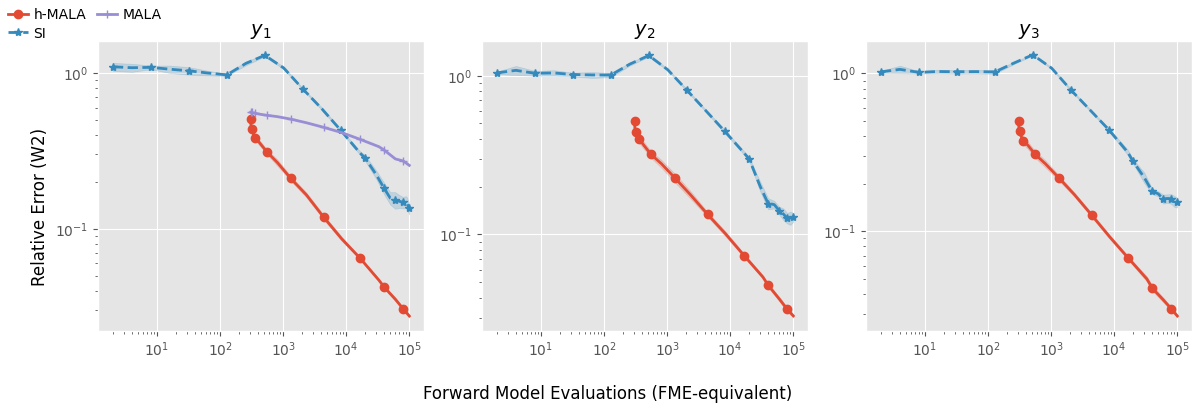

In [12]:
prior_error = 1.0  # error at 2 samples from prior-init chain, proxy for "starting at the prior"

# ---- cost conversion ----
si_fme_factor = 1.0          # SI: 1 step = 1 FME
mcmc_fme_factor = 2.0        # h-MALA: 1 cached step ~= 2 FMEs (1 forward + 1 adjoint)

# If these are currently measured in h-MALA step counts / gradient eval counts,
# convert them to FME-equivalent cost:
nevals_norm = 300
nevals_mod = 300
nevals_rare = 300
nevals_norm_fme = mcmc_fme_factor * nevals_norm
nevals_mod_fme  = mcmc_fme_factor * nevals_mod
nevals_rare_fme = mcmc_fme_factor * nevals_rare

# x-values
si_x = si_fme_factor * np.array(sample_no_list)
mcmc_x_norm = nevals_norm + mcmc_fme_factor * np.array(sample_no_list)[:-5]
mcmc_x_mod  = nevals_mod  + mcmc_fme_factor * np.array(sample_no_list)[:-5]
mcmc_x_rare = nevals_rare + mcmc_fme_factor * np.array(sample_no_list)[:-5]


fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# --- norm (y=0) ---
l0, = ax[0].plot(
    mcmc_x_norm, mcmc_main_avg,
    marker="o", markevery=2, linewidth=2, markersize=6, label="h-MALA",
)
ax[0].fill_between(
    mcmc_x_norm,
    np.maximum(mcmc_main_avg - mcmc_main_std, 1e-10),
    mcmc_main_avg + mcmc_main_std,
    alpha=0.2, color=l0.get_color()
)
l1, = ax[0].plot(
    si_x, si_main_avg,
    marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2, label="SI",
)
ax[0].fill_between(
    si_x,
    np.maximum(si_main_avg - si_main_std, 1e-10),
    si_main_avg + si_main_std,
    alpha=0.2, color=l1.get_color()
)
ax[0].plot(
    mcmc_x_norm, mala_swd[:-1], marker="+", markevery=2, linewidth=2, markersize=6, label="MALA",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_1$", fontsize=14, pad=4)

# --- mod (y=-1) ---
l0, = ax[1].plot(
    mcmc_x_mod, mcmc_med_avg,
    marker="o", markevery=2, linewidth=2, markersize=6
)
ax[1].fill_between(
    mcmc_x_mod,
    np.maximum(mcmc_med_avg - mcmc_med_std, 1e-10),
    mcmc_med_avg + mcmc_med_std,
    alpha=0.2, color=l0.get_color()
)
l1, = ax[1].plot(
    si_x, si_med_avg,
    marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2
)
ax[1].fill_between(
    si_x,
    np.maximum(si_med_avg - si_med_std, 1e-10),
    si_med_avg + si_med_std,
    alpha=0.2, color=l1.get_color()
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=14, pad=4)

# --- rare (y=-4.2) ---
l0, = ax[2].plot(
    mcmc_x_rare, mcmc_98_avg,
    marker="o", markevery=2, linewidth=2, markersize=6, label="h-MALA"
)
ax[2].fill_between(
    mcmc_x_rare,
    np.maximum(mcmc_98_avg - mcmc_98_std, 1e-10),
    mcmc_98_avg + mcmc_98_std,
    alpha=0.2, color=l0.get_color()
)
l1, = ax[2].plot(
    si_x, si_98_avg,
    marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2, label="SI (ODE)"
)
ax[2].fill_between(
    si_x,
    np.maximum(si_98_avg - si_98_std, 1e-10),
    si_98_avg + si_98_std,
    alpha=0.2, color=l1.get_color()
)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_3$", fontsize=14, pad=4)

fig.supxlabel("Forward Model Evaluations (FME-equivalent)")
fig.supylabel("Relative Error (W2)")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=0.8,
    labelspacing=0.3,
    borderaxespad=0.2,
)

plt.tight_layout()
# plt.savefig("images/lv-conv.pdf")

In [8]:
mcmc_main_avg

array([0.4190567 , 0.37108776, 0.3190843 , 0.29551042, 0.26339615,
       0.20085859, 0.13931027, 0.10534456, 0.08082771, 0.05867012,
       0.04211468, 0.02858532, 0.0201837 , 0.01327149, 0.01261496,
       0.01098216, 0.00916123, 0.0083761 ])

In [9]:
mcmc_med_avg

array([0.29866975, 0.27343388, 0.24268787, 0.20871855, 0.17144838,
       0.14194002, 0.09981469, 0.07256868, 0.05078228, 0.03559538,
       0.02561426, 0.01856696, 0.01313721, 0.00891261, 0.00838573,
       0.00686079, 0.00605601, 0.00546655])